### Measures of Dispersion / Variability (Spread)

- While central tendency gives us the center of a dataset, **measures of dispersion** describe how spread out or clustered the data points are around that center.

- Below are clear, naive examples covering the primary measures of dispersion, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across **Plain Python**, **Standard Library `statistics`**, and **`NumPy`** / **`SciPy`**.
---
---

### Setup

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics
import scipy.stats as stats


# set style for plots
plt.style.use('seaborn_v0_8_white' if 'seaborn_v0_8_white' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100 # set the dpi
# seed 
np.random.seed(42)


--- 
## 1. Range (Spread from Minimum to Maximum)

* **What it does:** Measures the total span between the largest and smallest observations.
* **Mathematical Notation:**
  $$R = x_{\max} - x_{\min}$$
  *Where:*
  * $R$ (*R*): Range
  * $x_{\max}$ (*x max*): Maximum value in the dataset
  * $x_{\min}$ (*x min*): Minimum value in the dataset
* **Naive Example:** Daily high temperatures over a week: `[18, 20, 22, 25, 30]` ($x_{\min} = 18, x_{\max} = 30$).
  $$R = 30 - 18 = 12^\circ\text{C}$$
* **When to use:** For quick, high-level checks where simple boundaries are needed.

Plain Python calculation:      12°C
NumPy (np.max - np.min):        12°C
NumPy (np.ptp):                12°C


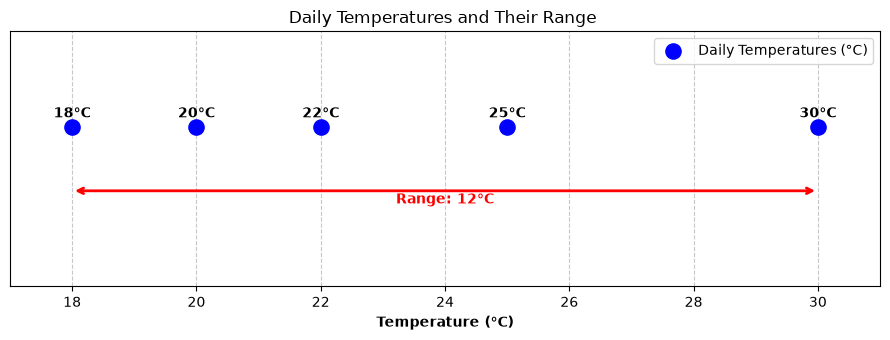

In [4]:
# 1. Range Example
temperatures = [18, 20, 22, 25, 30]
min_val,max_val = min(temperatures), max(temperatures)
range_python = max(temperatures) - min(temperatures) # Plain Python


range_np_minmax = np.max(temperatures) - np.min(temperatures) # NumPy - Method A: Expressive Min/Max (Recommended in modern NumPy)

# NumPy - Method B: Peak-to-Peak function
range_np_ptp = np.ptp(temperatures)  # 'ptp' stands for peak-to-peak

print(f"Plain Python calculation:      {range_python}°C")
print(f"NumPy (np.max - np.min):        {range_np_minmax}°C")
print(f"NumPy (np.ptp):                {range_np_ptp}°C")


# generate visualization for the range
plt.figure(figsize=(9, 3.5))
plt.scatter(temperatures, [1]*len(temperatures), color='blue', s=120, zorder=2, label="Daily Temperatures (°C)")
# Each point Annotation
for i, temp in enumerate(temperatures):
    plt.text(temp, 1.02, f"{temp}°C", ha='center', va='bottom', fontsize=10,fontweight='bold')

# parameters used in annotate
# arrowprops : dictionary of properties for the arrow
# arrowstyle="<->" creates a double-headed arrow
# lw=2 sets the line width of the arrow to 2
plt.annotate("",xy=(min_val, 0.8), xytext=(max_val, 0.8),
             arrowprops=dict(arrowstyle="<->", color='red', lw=2))
plt.text((min_val + max_val) / 2, 0.75, f"Range: {range_python}°C", ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

plt.ylim(0.5, 1.3)
plt.xlim(min(temperatures) - 1, max(temperatures) + 1)
plt.yticks([])
plt.xlabel("Temperature (°C)",fontweight='bold')
plt.title("Daily Temperatures and Their Range ")
plt.grid(True, linestyle='--', alpha=0.7,axis='x')
plt.legend()
plt.tight_layout() # Adjust subplots to fit into figure area.
plt.show()


--- 
## 2. Interquartile Range (IQR - Middle 50% Spread)

* **What it does:** Measures the spread of the middle 50% of data, ignoring extreme top and bottom tail values.
* **Mathematical Notation:**
  $$\text{IQR} = Q_3 - Q_1$$
  *Where:*
  * $\text{IQR}$ (*I-Q-R*): Interquartile Range
  * $Q_1$ (*Q one*): 25th percentile (first quartile)
  * $Q_3$ (*Q three*): 75th percentile (third quartile)
* **Naive Example:** Exam scores: `[10, 50, 60, 70, 80, 85, 100]`. $Q_1 = 50$ and $Q_3 = 85$.
  $$\text{IQR} = 85 - 50 = 35 \text{ marks}$$
* **When to use:** When data has heavy outliers or skewness (e.g., house prices, incomes).

In [5]:
# ---------------------------------------------------------
# 1. Core / Pure Python (From Scratch via Linear Interpolation)
# ---------------------------------------------------------
def get_percentile_linear(data, percentile):
    """Calculates percentile using linear interpolation (NumPy default equivalent)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Fractional index position
    index = (percentile / 100) * (n - 1)
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

def get_percentile_weibull(data, percentile):
    """Calculates percentile using the Weibull method (similar to Excel's PERCENTILE.INC)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Weibull formula for percentile rank
    rank = (percentile / 100) * (n + 1)
    index = rank - 1 # why -1 ? Because the formula calculates a 1-based index, but Python uses 0-based indexing.
    if index < 0:
        return sorted_data[0]
    elif index >= n - 1:
        return sorted_data[-1]
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

scores = [10, 50, 60, 70, 80, 85, 100]

# Example usage
q1_linear = get_percentile_linear(scores, 25)
q3_linear = get_percentile_linear(scores, 75)
iqr_linear = q3_linear - q1_linear

# exclusive corresponds to the linear method in the statistics module
q1_stats_linear,_,q3_stats_linear = statistics.quantiles(scores, n=4, method='exclusive')
iqr_stats_linear = q3_stats_linear - q1_stats_linear

# in statistics module, the 'inclusive' method corresponds to the Weibull method

# using statistics.quantiles with the Weibull method
q1_stats_weibull,_,q3_stats_weibull = statistics.quantiles(scores, n=4, method='inclusive')
iqr_stats_weibull = q3_stats_weibull - q1_stats_weibull

# using numpy np.percentile (linear interpolation)

q1_np_linear = np.percentile(scores, 25, method='linear')
q3_np_linear = np.percentile(scores, 75, method='linear')
iqr_np_linear = q3_np_linear - q1_np_linear

# using numpy np.percentile (Weibull method)
q1_np_weibull = np.percentile(scores, 25, method='weibull')
q3_np_weibull = np.percentile(scores, 75, method='weibull')
iqr_np_weibull = q3_np_weibull - q1_np_weibull


q1_weibull = get_percentile_weibull(scores, 25)
q3_weibull = get_percentile_weibull(scores, 75)
iqr_weibull = q3_weibull - q1_weibull


# let us print All as a table using string formatiing
print(f"{'Method':<35}{'Q1':<10}{'Q3':<10}{'IQR':<10}")
print(f"{'-'*65}")
print(f"{'Linear (custom function)':<35}{q1_linear:<10}{q3_linear:<10}{iqr_linear:<10}")
print(f"{'Linear (statistics module)':<35}{q1_stats_linear:<10}{q3_stats_linear:<10}{iqr_stats_linear:<10}")
print(f"{'Weibull (statistics module)':<35}{q1_stats_weibull:<10}{q3_stats_weibull:<10}{iqr_stats_weibull:<10}")
print(f"{'Linear (numpy)':<35}{q1_np_linear:<10}{q3_np_linear:<10}{iqr_np_linear:<10}")
print(f"{'Weibull (numpy)':<35}{q1_np_weibull:<10}{q3_np_weibull:<10}{iqr_np_weibull:<10}")
print(f"{'Weibull (custom function)':<35}{q1_weibull:<10}{q3_weibull:<10}{iqr_weibull:<10}")




Method                             Q1        Q3        IQR       
-----------------------------------------------------------------
Linear (custom function)           55.0      82.5      27.5      
Linear (statistics module)         50.0      85.0      35.0      
Weibull (statistics module)        55.0      82.5      27.5      
Linear (numpy)                     55.0      82.5      27.5      
Weibull (numpy)                    50.0      85.0      35.0      
Weibull (custom function)          50.0      85.0      35.0      


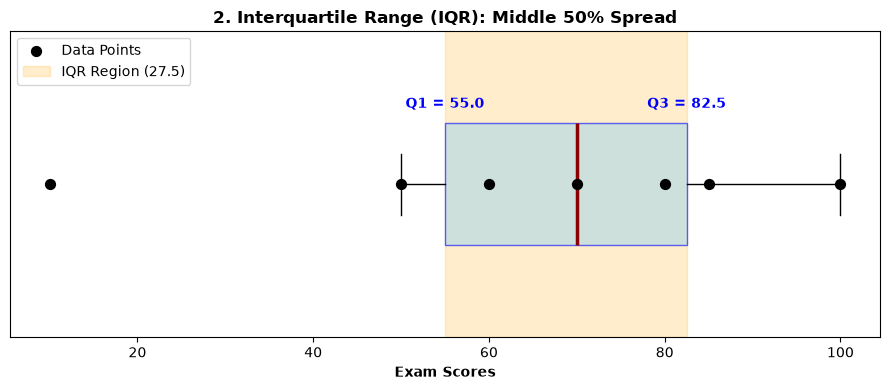

In [6]:
scores = [10, 50, 60, 70, 80, 85, 100]
q1 = np.percentile(scores, 25, method='linear')
q3 = np.percentile(scores, 75, method='linear')
iqr = q3 - q1

fig, ax = plt.subplots(figsize=(9, 4))

# Plot horizontal boxplot
bp = ax.boxplot(scores, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))

# Plot raw points
ax.scatter(scores, [1] * len(scores), color='black', zorder=4, label='Data Points', s=50)

# Highlight IQR span
ax.axvspan(q1, q3, color='orange', alpha=0.2, label=f'IQR Region ({iqr:.1f})')

# Annotate Q1 and Q3
ax.text(q1, 1.25, f'Q1 = {q1:.1f}', ha='center', color='blue', fontweight='bold')
ax.text(q3, 1.25, f'Q3 = {q3:.1f}', ha='center', color='blue', fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Exam Scores', fontweight='bold')
ax.set_title('2. Interquartile Range (IQR): Middle 50% Spread', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

--- 
## 3. Sample Variance (Average Squared Deviations)

* **What it does:** Measures how far points deviate from the mean on average, squared so positive and negative differences do not cancel out.
* **Mathematical Notation:**
  $$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$
  *Where:*
  * $s^2$ (*s squared*): Sample variance
  * $n-1$ (*n minus one*): Bessel's correction for sample bias
  * $x_i$ (*x sub i*): i-th observation
  * $\bar{x}$ (*x-bar*): Sample mean
  * $\sum$ (*capital Sigma*): Summation operator
* **Naive Example:** Heights of 3 plants in cm: `[10, 20, 30]` ($n = 3$, $\bar{x} = 20$). Deviations are $(-10, 0, 10)$, squared deviations are $(100, 0, 100)$.
  $$s^2 = \frac{100 + 0 + 100}{3 - 1} = \frac{200}{2} = 100 \text{ cm}^2$$
* **When to use:** Foundation for inferential statistics and risk modeling (units are squared).

In [7]:
# 3. Sample Variance Example
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_python = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)

# Standard Library (statistics)
var_stats = statistics.variance(plants)

# use numpy for variance
var_np = np.var(plants,ddof=1) # ddof =1 Bessel's correction

print(f"Plain Python calculation:  {var_python:.1f} cm²")
print(f"statistics.variance():      {var_stats:.1f} cm²")
print(f"np.var(ddof=1):            {var_np:.1f} cm²")



Plain Python calculation:  100.0 cm²
statistics.variance():      100.0 cm²
np.var(ddof=1):            100.0 cm²


--- 
#### 4. Sample Standard Deviation (Spread in Original Units)

* **What it does:** Converts variance back into original measurement units by taking the square root.
* **Mathematical Notation:**
  $$s = \sqrt{s^2} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$
  *Where:*
  * $s$ (*s*): Sample standard deviation
  * $s^2$ (*s squared*): Sample variance
  * $\sqrt{\cdot}$ (*square root*): Square root operator
* **Naive Example:** Using plant heights `[10, 20, 30]` with sample variance $s^2 = 100\text{ cm}^2$:
  $$s = \sqrt{100} = 10\text{ cm}$$
* **When to use:** Primary metric for describing spread in standard units alongside the mean.

In [8]:
# 4. Sample Standard Deviation Example
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_val = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)
std_python = math.sqrt(var_val)

# Standard Library (statistics)
std_stats = statistics.stdev(plants)

# NumPy Library (ddof=1 specifies sample standard deviation)
std_np = np.std(plants, ddof=1)

print(f"Plain Python calculation:  {std_python:.1f} cm")
print(f"statistics.stdev():        {std_stats:.1f} cm")
print(f"np.std(ddof=1):            {std_np:.1f} cm")


Plain Python calculation:  10.0 cm
statistics.stdev():        10.0 cm
np.std(ddof=1):            10.0 cm


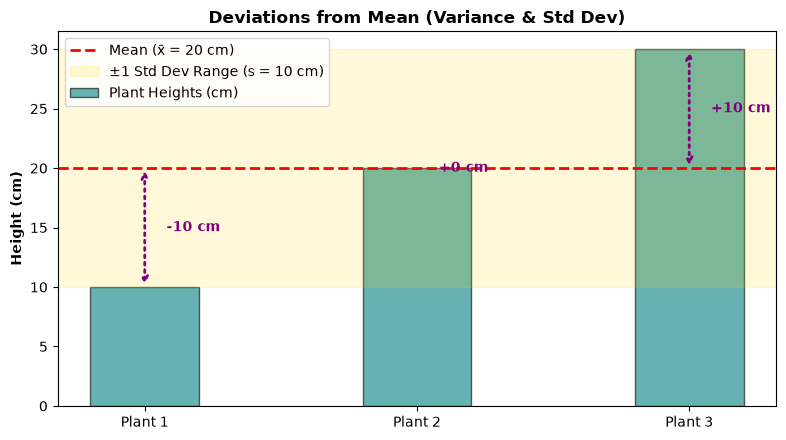

In [ ]:
plants = [10, 20, 30]
mean_val = np.mean(plants)
std_val = np.std(plants, ddof=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
x_indices = np.arange(1, len(plants) + 1)
bars = ax.bar(x_indices, plants, width=0.4, color='teal', alpha=0.6, label='Plant Heights (cm)', edgecolor='black')

# Draw Mean Line
ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (x̄ = {mean_val:.0f} cm)')

# Draw deviation vectors
for idx, h in zip(x_indices, plants):
    ax.annotate('', xy=(idx, h), xytext=(idx, mean_val),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2, linestyle=':'))
    dev = h - mean_val
    ax.text(idx + 0.08, (h + mean_val) / 2, f'{dev:+0.0f} cm', color='purple', fontweight='bold', va='center')


# Highlight ±1 Std Dev Band
ax.axhspan(mean_val - std_val, mean_val + std_val, color='gold', alpha=0.15, label=f'±1 Std Dev Range (s = {std_val:.0f} cm)')

ax.set_xticks(x_indices)
ax.set_xticklabels([f'Plant {i}' for i in x_indices])
ax.set_ylabel('Height (cm)', fontweight='bold')
ax.set_title('Deviations from Mean (Variance & Std Dev)', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Real-World Decision Examples

### Use **Sample Variance** ($n - 1$) when:
* **Manufacturing / QA:** Testing 50 light bulbs out of a factory batch of 10,000 to check life expectancy variance.
* **Polling & Surveys:** Surveying 1,000 voters to estimate the variation in voting preference across a country of 50 million.
* **Machine Learning / Data Science:** Computing feature variance on a training set to generalize to unseen test/production data.
* **Medical Clinical Trials:** Measuring blood pressure changes in 100 trial patients to infer variability for all future patients.

### Use **Population Variance** ($N$) when:
* **Complete Census:** Analyzing test scores for all 30 students in a single class, where you only care about that specific class (not all students worldwide).
* **Closed Systems:** Evaluating the variance of monthly revenue across all 12 months of a completed fiscal year.
* **Full Dataset Operations:** Scaling/standardizing a fixed, self-contained matrix where no external inference will be made.

In [ ]:
# Dataset representing the ENTIRE population of 3 plant heights (in cm)
plants = [10, 20, 30]
N = len(plants)
mu = sum(plants) / N

# --- 1. POPULATION VARIANCE & STD DEV (ddof = 0) ---
# Plain Python
pop_var_py = sum((x - mu) ** 2 for x in plants) / N
pop_std_py = math.sqrt(pop_var_py)

# Standard Library
pop_var_stats = statistics.pvariance(plants)
pop_std_stats = statistics.pstdev(plants)

# NumPy (ddof=0 by default)
pop_var_np = np.var(plants, ddof=0)
pop_std_np = np.std(plants, ddof=0)

print("--- POPULATION (Entire Census) ---")
print(f"Population Variance (σ²): {pop_var_np:.2f} cm² (Python: {pop_var_py:.2f}, stats: {pop_var_stats:.2f})")
print(f"Population Std Dev  (σ):  {pop_std_np:.2f} cm  (Python: {pop_std_py:.2f}, stats: {pop_std_stats:.2f})")


# --- 2. SAMPLE VARIANCE & STD DEV (ddof = 1) ---
# Plain Python
sample_var_py = sum((x - mu) ** 2 for x in plants) / (N - 1)
sample_std_py = math.sqrt(sample_var_py)

# Standard Library
sample_var_stats = statistics.variance(plants)
sample_std_stats = statistics.stdev(plants)

# NumPy (requires explicit ddof=1)
sample_var_np = np.var(plants, ddof=1)
sample_std_np = np.std(plants, ddof=1)

print("\n--- SAMPLE (Subset / Estimation) ---")
print(f"Sample Variance (s²):     {sample_var_np:.2f} cm² (Python: {sample_var_py:.2f}, stats: {sample_var_stats:.2f})")
print(f"Sample Std Dev  (s):      {sample_std_np:.2f} cm  (Python: {sample_std_py:.2f}, stats: {sample_std_stats:.2f})")

--- POPULATION (Entire Census) ---
Population Variance (σ²): 66.67 cm² (Python: 66.67, stats: 66.67)
Population Std Dev  (σ):  8.16 cm  (Python: 8.16, stats: 8.16)

--- SAMPLE (Subset / Estimation) ---
Sample Variance (s²):     100.00 cm² (Python: 100.00, stats: 100.00)
Sample Std Dev  (s):      10.00 cm  (Python: 10.00, stats: 10.00)


--- 
## 5. Mean Absolute Deviation (MAD)

* **What it does:** Calculates the average absolute distance of all data points from the mean without squaring.
* **Mathematical Notation:**
  $$\text{MAD} = \frac{1}{n} \sum_{i=1}^{n} \vert{}x_i - \bar{x}\vert{}$$
  *Where:*
  * $\text{MAD}$ (*M-A-D*): Mean Absolute Deviation
  * $\vert{}\cdot\vert{}$ (*absolute value bars*): Absolute value operator (discards negative signs)
  * $n$ (*n*): Total observations
  * $\bar{x}$ (*x-bar*): Sample mean
* **Naive Example:** 3 daily deliveries in minutes: `[10, 20, 30]` ($\bar{x} = 20$). Absolute deviations are $\vert{}10-20\vert{} = 10, \vert{}20-20\vert{} = 0, \vert{}30-20\vert{} = 10$.
  $$\text{MAD} = \frac{10 + 0 + 10}{3} = \frac{20}{3} \approx 6.67 \text{ minutes}$$
* **When to use:** Highly intuitive spread metric that is less sensitive to extreme outliers than standard deviation.

Plain Python calculation: 6.67 minutes
NumPy vector operations:   6.67 minutes


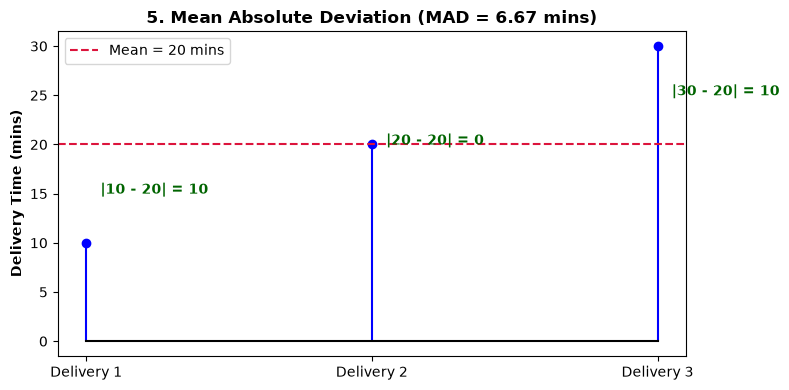

In [23]:
# 5. Mean Absolute Deviation Example
deliveries = [10, 20, 30]

# Plain Python
mean_val = sum(deliveries) / len(deliveries)
mad_python = sum(abs(x - mean_val) for x in deliveries) / len(deliveries)

# NumPy Library
mad_np = np.mean(np.abs(np.array(deliveries) - np.mean(deliveries)))

print(f"Plain Python calculation: {mad_python:.2f} minutes")
print(f"NumPy vector operations:   {mad_np:.2f} minutes")


mean_val = np.mean(deliveries)
mad_val = np.mean(np.abs(np.array(deliveries) - mean_val))
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(deliveries))
ax.stem(x, deliveries, linefmt='b-', markerfmt='bo', basefmt='k-')

# Mean line
ax.axhline(mean_val, color='crimson', linestyle='--', label=f'Mean = {mean_val:.0f} mins')

# Annotate absolute distances
for i, d in enumerate(deliveries):
    abs_dev = abs(d - mean_val)
    ax.text(i + 0.05, (d + mean_val) / 2, f'|{d} - {mean_val:.0f}| = {abs_dev:.0f}', 
            color='darkgreen', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Delivery {i+1}' for i in x])
ax.set_ylabel('Delivery Time (mins)', fontweight='bold')
ax.set_title(f'5. Mean Absolute Deviation (MAD = {mad_val:.2f} mins)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

--- 
## 6. Median Absolute Deviation (Median MAD)

* **What it does:** Measures robust dispersion by computing the median of absolute differences from the data's median.
* **Mathematical Notation:**
  $$\text{MAD}_{\text{med}} = \text{median}\left( \vert{}x_i - \tilde{x}\vert{} \right)$$
  *Where:*
  * $\text{MAD}_{\text{med}}$ (*median MAD*): Median Absolute Deviation
  * $\tilde{x}$ (*x-tilde*): Median of the dataset
  * $\vert{}x_i - \tilde{x}\vert{}$ (*absolute difference*): Distance of each point from the median
* **Naive Example:** Hourly wages: `[10, 12, 15, 20, 100]` ($\tilde{x} = 15$). Deviations from median: $\vert{}10-15\vert{}=5, \vert{}12-15\vert{}=3, \vert{}15-15\vert{}=0, \vert{}20-15\vert{}=5, \vert{}100-15\vert{}=85$. Sorted deviations: `[0, 3, 5, 5, 85]`.
  $$\text{MAD}_{\text{med}} = 5$$
* **When to use:** Extreme outlier situations where standard deviation and mean absolute deviation fail.

In [27]:

# 6. Median Absolute Deviation Example
wages = [10, 12, 15, 20, 100]

# Plain Python
med_val = statistics.median(wages)
devs = [abs(x - med_val) for x in wages]
mad_med_python = statistics.median(devs)

# NumPy Library
mad_med_np = np.median(np.abs(np.array(wages) - np.median(wages)))

# SciPy Library
mad_med_scipy = stats.median_abs_deviation(wages, scale=1)

print(f"Plain Python calculation: ${mad_med_python:.2f}")
print(f"NumPy calculation:        ${mad_med_np:.2f}")
print(f"scipy.stats.median_abs_deviation(): ${mad_med_scipy:.2f}")

Plain Python calculation: $5.00
NumPy calculation:        $5.00
scipy.stats.median_abs_deviation(): $5.00


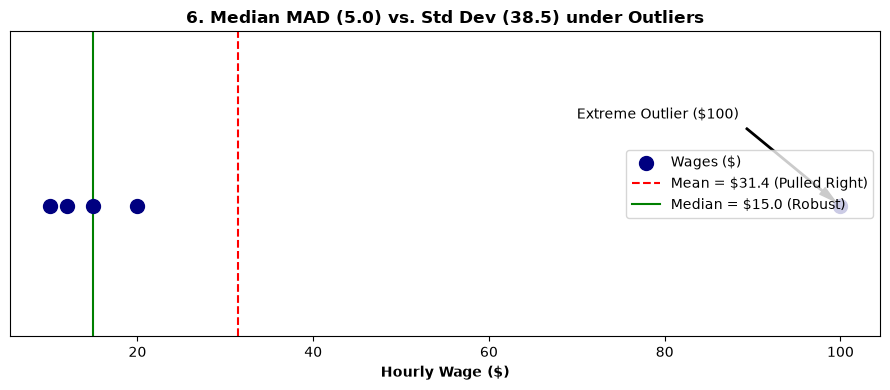

In [28]:

# 6. Median Absolute Deviation Visualization (With Outliers)
wages = [10, 12, 15, 20, 100]
med_val = np.median(wages)
mean_val = np.mean(wages)
std_val = np.std(wages, ddof=1)
mad_med = stats.median_abs_deviation(wages, scale=1)

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(wages, [1] * len(wages), color='navy', s=100, zorder=3, label='Wages ($)')

# Annotate Outlier
ax.annotate('Extreme Outlier ($100)', xy=(100, 1), xytext=(70, 1.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Lines for Mean vs Median
ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean = ${mean_val:.1f} (Pulled Right)')
ax.axvline(med_val, color='green', linestyle='-', label=f'Median = ${med_val:.1f} (Robust)')

ax.set_ylim(0.7, 1.4)
ax.set_yticks([])
ax.set_xlabel('Hourly Wage ($)', fontweight='bold')
ax.set_title(f'6. Median MAD ({mad_med:.1f}) vs. Std Dev ({std_val:.1f}) under Outliers', fontweight='bold')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

--- 
## 7. Coefficient of Variation (Relative Variability)

* **What it does:** Measures relative spread as a percentage ratio of standard deviation to mean, allowing comparisons across different units or scales.
* **Mathematical Notation:**
  $$\text{CV} = \frac{s}{\bar{x}} \times 100\%$$
  *Where:*
  * $\text{CV}$ (*C-V*): Coefficient of Variation
  * $s$ (*s*): Sample standard deviation
  * $\bar{x}$ (*x-bar*): Sample mean
* **Naive Example:** 
- Stocks A and B. Stock A ($\bar{x} = \$10, s = \$2 \implies \text{CV} = 20\%$) vs 
- Stock B ($\bar{x} = \$100, s = \$5 \implies \text{CV} = 5\%$). 
- Stock A has higher relative risk.
* **When to use:** Comparing variability between datasets with different measurement scales (e.g., comparing income variability in USD vs Yen).

In [29]:
# 7. Coefficient of Variation Example
prices = [10, 12, 15, 18, 20]
# Plain Python
mean_val = sum(prices) / len(prices)
std_val = statistics.stdev(prices)
cv_python = (std_val / mean_val) * 100

# SciPy Library (stats.variation returns proportion; multiply by 100 for %)
cv_scipy_1 = stats.variation(prices) * 100 # uses population standard deviation(N) (ddof=0) by default
cv_scipy_2 = stats.variation(prices,ddof=1) * 100 # uses sample standard deviation(N-1) (ddof=1)

print(f"Plain Python calculation: {cv_python:.2f}%")
print(f"scipy.stats.variation() (population, ddof=0):  {cv_scipy_1:.2f}%")
print(f"scipy.stats.variation() (sample, ddof=1):      {cv_scipy_2:.2f}%")

Plain Python calculation: 27.49%
scipy.stats.variation() (population, ddof=0):  24.59%
scipy.stats.variation() (sample, ddof=1):      27.49%


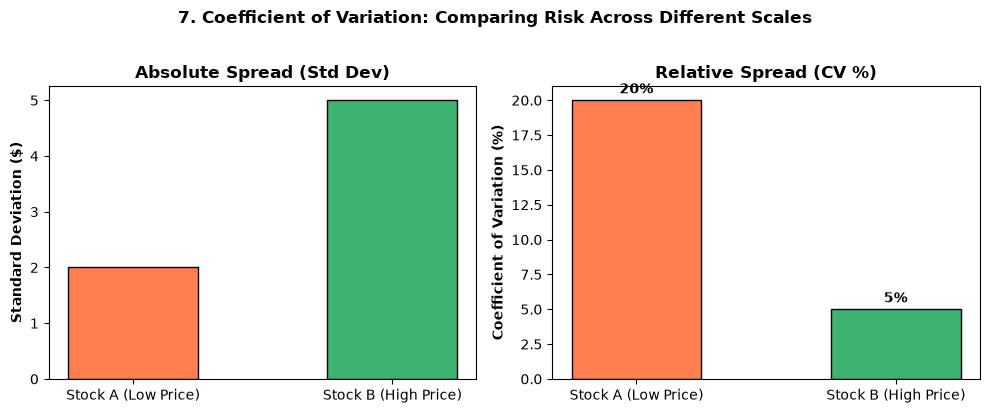

In [30]:

# 7. Coefficient of Variation Visualization
means = [10, 100]
stds = [2, 5]
cvs = [(s / m) * 100 for m, s in zip(means, stds)]
labels = ['Stock A (Low Price)', 'Stock B (High Price)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Chart 1: Absolute Standard Deviation
ax1.bar(labels, stds, color=['coral', 'mediumseagreen'], edgecolor='black', width=0.5)
ax1.set_ylabel('Standard Deviation ($)', fontweight='bold')
ax1.set_title('Absolute Spread (Std Dev)', fontweight='bold')

# Chart 2: Relative Variation (CV %)
bars2 = ax2.bar(labels, cvs, color=['coral', 'mediumseagreen'], edgecolor='black', width=0.5)
ax2.set_ylabel('Coefficient of Variation (%)', fontweight='bold')
ax2.set_title('Relative Spread (CV %)', fontweight='bold')

for bar, cv in zip(bars2, cvs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cv:.0f}%', 
             ha='center', fontweight='bold')

plt.suptitle('7. Coefficient of Variation: Comparing Risk Across Different Scales', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### previous cell explained
### 1. Plain Python Calculation (Sample Std Dev, $n - 1 = 4$)

`statistics.stdev()` calculates sample standard deviation:
- prices = [10, 12, 15, 18, 20]
$$s = \sqrt{\frac{(10-15)^2 + (12-15)^2 + (15-15)^2 + (18-15)^2 + (20-15)^2}{5 - 1}} = \sqrt{\frac{68}{4}} = \mathbf{4.1231}$$

$$\text{CV}_{\text{python}} = \left(\frac{4.1231}{15.0}\right) \times 100\% = \mathbf{27.49\%}$$

---

### 2. SciPy Calculation (Population Std Dev, $N = 5$)

By default, `stats.variation()` divides by $N$ (`ddof=0`):

$$\sigma = \sqrt{\frac{68}{5}} = \mathbf{3.6878}$$

$$\text{CV}_{\text{scipy}} = \left(\frac{3.6878}{15.0}\right) \times 100\% = \mathbf{24.59\%}$$